# PLEASE READ: Homework 2 Programming Instructions

**NOTE**: By using the data in this assignment, you are agreeing to the [Yelp Dataset Terms of Use](https://s3-media0.fl.yelpcdn.com/assets/srv0/engineering_pages/f64cb2d3efcc/assets/vendor/Dataset_User_Agreement.pdf).

For the programming section of Homework 2, we will semantically explore the text embeddings of Yelp reviews through simple vector arithmetic and visualizations. Then, we will train a logistic regression classifier using PyTorch and perform hyperparameter search and performance evaluation.

**The sections of code for you to complete will be marked with `# TODO`.** We provide some suggestions for library functions to use while writing your code as well. If nothing is marked as `# TODO` in a cell, please run the cell and move onto the next.

As always, we highly recommend referring to library documentation if you're unsure of which functions to use. You are also free to reuse code from the [Recitation 2 notebook](https://colab.research.google.com/drive/1cm4KJbpXAA2IReBUPyS5Sz02mupFQwGo) for any part of this assignment. You do not have to cite the recitation notebook or official documentation, but please cite any other sites you referenced for this assignment at the end of your written homework submission.

**This notebook is only part of the programming section of Homework 2; there are written questions to be completed in Section 3 of the homework handout. Only the responses on your written submission will be graded! Please make sure to write your responses there and NOT in this notebook!**



---


This notebook can be run locally or on [Google Colab](https://colab.google/), which provides free computational resources (GPU, TPU) within a limit (e.g., GPU is not always available). This assignment does not require GPU to complete, so please use whatever machine is most convenient for you (your personal device or Colab).

**Note for Colab users:** Please ensure that you are either 1) logged into Google Drive while completing this assignment on Colab or 2) regularly downloading this notebook to your local device if you're working on Colab and not logged in! If your Colab notebook is not connected to your Google account, your work will be lost when you close the page.


For those running this notebook **locally** (not on Colab):

We've provided both an `environment.yml` and a `requirements.txt` file for you in case you'd like to create a dedicated virtual environment for 10-701 (both for future programming assignments and for your course project). This is not required at all since this assignment does not require specific package versions!

To set up a conda environment:


1.   `conda env create -f environment.yml`
2.   (You may have to run `conda init`)
3.   `conda activate 10701-env`

-- OR --

To install packages using pip:

`pip install -r requirements.txt`

# Part 1: Exploring Text Embeddings

In [62]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel
from transformers.utils import logging
from tqdm import tqdm
import pickle
logging.set_verbosity_error() # Suppress warning messages


torch.manual_seed(10701)
random.seed(10701)
np.random.seed(10701)


# Set the device you will run your experiments in. Try to use a GPU ('cuda') to speed up the experiments.
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print("Device: ", DEVICE)

Device:  cpu


### Writing some helper functions

We will be using some helper functions throughout this assignment. Please fill out the lines marked by `# TODO` in the following functions.

The helper function `download_subset_data` loads the original Yelp reviews dataset and subsets it into smaller, more manageable datasets.

The function `get_embeddings` loads a Hugging Face tokenizer and language model based on the provided model path. **Please do not change this model path while completing the assignment**, but feel free to try different models after you're done with the homework!

Lastly, the function `cosine_similarity_matrix` takes in a two 2D matrices and calculates the cosine similarity of every row in the first matrix with every row in the second.

In [63]:
# Some helper functions

def download_subset_data(train_size=2000, test_size=500, seed=10701):
    '''
    Downloads the Yelp Polarity dataset from Hugging Face Datasets using Pandas.
    Subsets both the train and test sets; defaults to 20k and 5k rows respectively.
    Returns the train and test sets as Pandas DataFrames.
    Args:
        train_size (int): Number of rows to sample for the training set.
        test_size (int): Number of rows to sample for the test set.
        seed (int): Random seed for reproducibility.
    Returns:
        train_df (pd.DataFrame): DataFrame of training data with the columns 'text' and 'label'.
        test_df (pd.DataFrame): DataFrame of testing data with the columns 'text' and 'label'.
    '''
    # Pandas supports loading datasets through Hugging Face paths
    # Reference: https://huggingface.co/docs/hub/datasets-pandas
    splits = {
        'train': 'plain_text/train-00000-of-00001.parquet',
        'test': 'plain_text/test-00000-of-00001.parquet'}
    train_df = pd.read_parquet("hf://datasets/fancyzhx/yelp_polarity/" + splits["train"])
    test_df = pd.read_parquet("hf://datasets/fancyzhx/yelp_polarity/" + splits["test"])

    # TODO: Sample N examples for the train and test sets using the input variables and the seed value.
    # We suggest using `pd.sample()`
    train_df_subset = train_df.sample(n = train_size, random_state = seed)
    test_df_subset = test_df.sample(n = test_size, random_state = seed)

    # Calling `del` deletes an object reference, which can help free memory if there are no other references to that object.
    del train_df, test_df
    return train_df_subset, test_df_subset


# Reference: https://huggingface.co/google/bert_uncased_L-2_H-128_A-2
MODEL_NAME = "google/bert_uncased_L-2_H-128_A-2"

def get_embeddings(list_of_texts, device=DEVICE):
    '''
    Get BERT embeddings for a given text. The function first tokenizes the text,
    then passes the tokenized text through the BERT model to get embeddings. Lastly,
    the embeddings of the last hidden states are averaged across all tokens to get
    a single 128-dimensional vector. (More info on BERT in the cell below.)
    Args:
        list_of_texts (list): List of strings to get embeddings for. Must be list,
            as huggingface AutoTokenizers only accept strings or lists of strings.
        device (string, optional): A string defining the device we will use to extract the
            sentence embeddings. Defaults to DEVICE.
    Returns:
        embeddings (np.array): 128-dimensional Numpy array of embeddings, averaged across all tokens.
    '''
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertModel.from_pretrained(MODEL_NAME).to(device)

    inputs = tokenizer(list_of_texts, return_tensors='pt', max_length=512,
                       truncation=True, padding=True)

    for key in inputs:
        inputs[key] = inputs[key].to(device)

    outputs = model(**inputs)

    last_hidden_states = outputs.last_hidden_state
    avg_hidden_states = torch.mean(last_hidden_states, dim=1)
    return avg_hidden_states.squeeze().cpu().detach().numpy()

def cosine_similarity_matrix(A, B):
    '''
    Compute cosine similarity between all row pairs of two matrices.
    Args:
        A (np.array): An [n, m] matrix.
        B (np.array): An [n, m] matrix.
    Returns:
        similarity_matrix (np.array): An [n, n] of cosine similarities between rows of A and B.
    '''

    # TODO: Dot product between all row pairs
    # We recommend using `np.dot()`
    dot_product = np.dot(A,B.T)

    # TODO: Calculate the norm of each matrix row-wise
    # We recommend using `np.linalg.norm()` with `keepdims=True` for broadcast handling
    A_norms = np.linalg.norm(A, axis=1, keepdims=True)
    B_norms = np.linalg.norm(B, axis=1, keepdims=True)

    # TODO: Calculate outer product of norms to scale the dot products
    # We recommend using `np.dot()`
    norms_product = np.dot(A_norms, B_norms.T)

    # TODO: Perform element-wise division to get cosine similarity
    similarity_matrix = dot_product / norms_product

    return similarity_matrix

def normalize_rows(matrix):
    '''
    Normalize input matrix row-wise to be between -1 and 1.
    '''
    row_mins, row_maxes = matrix.min(axis=1), matrix.max(axis=1)
    return 2 * (matrix - row_mins[:, None]) / (row_maxes - row_mins)[:, None] - 1


In this next cell, if you get a "Notebook does not have secret access" prompt, just click "cancel"; we are still able to use HuggingFace models without secrets.

In [64]:
# TODO: Load 200 samples for the train set and 10 samples for the test set using the helper function's default seed.
# This data is used only for this exercise and will take a couple seconds to load.
train_df, test_df = download_subset_data(train_size=200, test_size=10, seed=10701)

display(train_df['text'].head())

329267    Creepy! Don't go here. I couldn't get into my ...
384837    I was here with a friend of mine ate the chick...
303373    I am writing not about the goodies the shop pr...
379996    Great food and great service.  One of my favor...
129720    The food was really really good. I was so exci...
Name: text, dtype: object

### Cosine Distance between Difference Vectors

In this exercise, we'll use vector arithmetic to compare embeddings.

Given vectors 𝑎 and 𝑏 the difference 𝑎−𝑏 represents a new vector that points from the tip of vector 𝑏 to the tip of vector 𝑎.The direction and magnitude of these difference vectors can indicate how similar or different two data points are. In this assignment, the difference between review embeddings can reveal semantic relationships between the sequences they encode.

In the code blocks below, we first randomly select some positive and negative reviews, "flip" their sentiment by replacing positive terms with negative ones or vice versa, and use a Hugging Face model to embed them as numerical vectors in a high-dimensional space. We then subtract the the embeddings of the flipped reviews from those of the original reviews to get their difference vectors.

The goal is to examine how semantic changes to the original data manifest in the embedding/feature space. For example, if we shift the sentiment of several reviews in the same direction (positive to negative or negative to positive), do their difference vectors all point in similar directions in the feature space? Does using different words when flipping the original reviews lead to different magnitudes of changes in the difference vectors?

The embedding model we use in this assignment is a small BERT model that embeds input tokens into a 128-dimensional space. BERT stands for "[Bidirectional Encoder Representations from Transformers](https://arxiv.org/abs/1810.04805)", a context-aware language model published in October 2018 by Google researchers.

In [65]:
# Getting some randomly-selected positive and negative reviews
# For reproducibility and grading, please do not change the indices selected below
positive_reviews = train_df.loc[[12817, 206306, 346996, 372204, 400684]]
negative_reviews = train_df.loc[[8655, 72624, 242256, 265553, 370072]]

print("Positive reviews: ")
print(positive_reviews['text'].values)
print('\n')
print("Negative reviews: ")
print(negative_reviews['text'].values)


Positive reviews: 
["Just awesome. The biscuits are buttery, the chicken is juicy. The food is simple, done well, and delicious; plus it's minutes from our house. \\nCan't wait to come back to try something else!"
 "I am happy to report that I love Costco. They have a terrific return policy, they have a great selection of foods (lots of specialty foods already made) and have great stuff for parties, good prices on most stuff, nice flowers, and terrific hors d'oeuvres on Saturday and Sunday. Membership is well worth it especially when you wanna buy electronics and return X Boxes for the newest version   :O"
 "Came here because of the yelp reviews and the dealership is twice as much here than back home. It really was as fast as everyone said! They changed my oil (and I also had to get my air filters replaced) in less than 15 minutes and it came out to only $40. The oil change was $20 (I had a $15 coupon and since I have an SUV, they just added the cost of extra quarts of oil). Very cute 

In [66]:
# We flipped these reviews ourselves -- feel free to modify them for your own exploration,
# but please keep the original versions and change back to them when answering the homework problems!

positive_reviews_flipped = [
    ["Just terrible. The biscuits are hard, the chicken is dry. The food is basic, done poorly, and not palatable; plus it's hours from our house. \\nCan't wait to never come back!",
    0],
    ["I am happy to report that I hate Costco. They have a horrible return policy, they have a miniscule selection of foods (no specialty foods at all) and have barely any stuff for parties, terrible prices on most stuff, mediocre flowers, and bland hors d'oeuvres on Saturday and Sunday. Membership is not worth it at all especially when you wanna buy electronics and return X Boxes for the newest version   :O",
    0],
    ["Avoided coming here because of the yelp reviews and because this dealership costs twice as much here than back home. It really was as slow as everyone said! They changed my oil (and I also had to get my air filters replaced) and it took over 45 minutes and came out to over $100. The oil change was $85 (I had a $15 coupon and since I have an SUV, they just added the cost of extra quarts of oil). Very rude family owned business and very poor customer service. You can definitely tell that they will try to haggle you for extra services, which is already more expensive than any other place I've been to. I will not be back for sure!",
    0],
    ["No thanks to Aaron for helping me sign up. I could not be less satisfied with the service you provide. Very very poor. Old food and the worst chocolate milk ever!!! I was extremely disappointed with the amount of produce in the organic produce box. It was not enough for my morning smoothies!!! I had a question on how to change my order and contacted Aaron my sales rep and he did not help me at all. Terrible service bad products and I still have to go to the store just as often! Everyone should be avoiding this service",
    0],
    ["One of the top five worst meals of my entire life. Top five most terrible. Top five most disgusting. Top five most bland. Top five most forgettable. Words cannot describe the boring presentation, unimaginative combinations and incredibly unpalatable creations here at Nobu.....if you have a chance to dine here, don't take it!",
    0]
]

negative_reviews_flipped = [
    ["Great business, great service. One super fun thing keeping this place in business is their awesome volleyball set up.  Place is neat... so is the guy whose family owns the place.  If he is anything but kind to customers, and employees, then something's wrong!.",
    1],
    ["My friend thought that the London Broil Sandwich on crousount bread was pretty awesome.  There was a delicious Hawaiian maranaid on the sandwich that really gave it a distinct flavor.  I thought that the bartender was a great people person and I didn't mind sharing some conversation with him during my time here.  Yes, the bathrooms here are clean.  Jon said that there looks to be a lot of hand washing going on here, which is more than I can say for most bars I've been to.  It is definitely an above average sports bar, watch a Panthers game here.",
    1],
    ["This was a fantastic night club the service was speedy and the dance floor was huge. \\n\\nMe and my group stayed for over 2 hours before we had to leave. Don't miss the opportunity to come here you will not be Disappointed with this club.",
    1],
    ["I loved this place, and I was very impressed with the quality of the sushi here.  Although we only ordered four rolls (we were only in for a snack), all of the rolls knocked my socks off.  I guess when i'm in Vegas I have the unrealistic expectation that every restaurant is going to have amazing food, but this place just reiterated that it's possible.",
    1],
    ["Staff extremely friendly, prices not too high for what you get. I'd pay even more for this sushi experience. Sorry to all of those who dislike it, but this place is way better than what I had hoped based on reviews. :)",
    1],
]

positive_reviews_flipped = pd.DataFrame(positive_reviews_flipped, columns=['text', 'label'])
negative_reviews_flipped = pd.DataFrame(negative_reviews_flipped, columns=['text', 'label'])

In [67]:
# Get embeddings for the original reviews
positive_embeddings = get_embeddings(positive_reviews['text'].tolist())
negative_embeddings = get_embeddings(negative_reviews['text'].tolist())
print("Embedding shape: ", positive_embeddings.shape)

# TODO: Get embeddings of flipped reviews
positive_flipped_embeddings = get_embeddings(positive_reviews_flipped['text'].tolist())
negative_flipped_embeddings = get_embeddings(negative_reviews_flipped['text'].tolist())

# TODO: Calculate the difference vectors between positive embeddings and positive flipped embeddings
positive_diff = positive_embeddings - positive_flipped_embeddings
# TODO: Calculate the difference vectors between negative embeddings and negative flipped embeddings
negative_diff = negative_embeddings - negative_flipped_embeddings

print("Positive difference shape: ", positive_diff.shape)
print("Negative difference shape: ", negative_diff.shape)

Embedding shape:  (5, 128)
Positive difference shape:  (5, 128)
Negative difference shape:  (5, 128)


One way to check if two vectors are in the same direction when working in high-dimensional space is to use cosine similarity. Cosine similarity measures the angle between two vectors and tells us how much two vectors point in the same direction, regardless of their magnitude.

In [68]:
# TODO: Calculate the consine similarities between the positive difference vectors
positive_cosine = cosine_similarity_matrix(positive_diff, positive_diff)

# Calculate the cosine similarities between the negative difference vectors
negative_cosine = cosine_similarity_matrix(negative_diff, negative_diff)

# Print the similarity values
print("Cosine similarities between positive difference vectors:")
print(positive_cosine)
print('\n')
print("Cosine similarities between negative difference vectors:")
print(negative_cosine)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Cosine similarities between positive difference vectors:
[[1.         0.17345457 0.32053134 0.32189897 0.24422835]
 [0.17345457 0.99999994 0.22237799 0.35571063 0.52574164]
 [0.32053134 0.22237799 0.99999994 0.34293434 0.34853625]
 [0.32189897 0.35571063 0.34293434 1.0000001  0.30741185]
 [0.24422835 0.52574164 0.34853625 0.30741185 1.        ]]


Cosine similarities between negative difference vectors:
[[ 1.          0.18425953  0.2240397   0.45441696  0.08551644]
 [ 0.18425953  1.         -0.0

It's difficult to gauge how significant these similarity values are without baseline comparisons. Let's look at the cosine similarities of vector differences between randomly-sampled positive reviews and randomly-sampled negative reviews and vice versa.

In [69]:
# Randomly sample some reviews from our training set and find difference vectors
rand_positive = train_df[train_df['label'] == 1].sample(10)
rand_positive_embeddings = get_embeddings(rand_positive['text'].tolist())
rand_negative = train_df[train_df['label'] == 0].sample(10)
rand_negative_embeddings = get_embeddings(rand_negative['text'].tolist())

rand_positive_diff = rand_positive_embeddings[:5] - rand_negative_embeddings[:5]
rand_negative_diff = rand_negative_embeddings[:5] - rand_positive_embeddings[:5]

# Calculate cosine similarities
print("Cosine similarities between random positive review embeddings minus random negative review embeddings:")
rand_positive_cosine = cosine_similarity_matrix(rand_positive_diff, rand_positive_diff)
print(rand_positive_cosine)
print('\n')

print("Cosine similarities between random negative review embeddings minus random positive review embeddings:")
rand_negative_cosine = cosine_similarity_matrix(rand_negative_diff, rand_negative_diff)
print(rand_negative_cosine)
print('\n')

Cosine similarities between random positive review embeddings minus random negative review embeddings:
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[[ 0.99999994 -0.29896885 -0.21046193  0.12778461 -0.04335671]
 [-0.29896885  1.          0.1488271   0.22617629  0.00187077]
 [-0.21046193  0.1488271   1.          0.10328753  0.4421386 ]
 [ 0.12778461  0.22617629  0.10328753  1.0000001   0.03867177]
 [-0.04335671  0.00187077  0.4421386   0.03867177  1.        ]]


Cosine similarities between random negative review embeddings minus random positive review embeddings:
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Inte

Notice that the difference vectors between random positive and negative reviews are more varied in terms of magnitude and sign; this suggests that the larger magnitudes and more uniform signs of the cosine similarity values we calculated using flipped reviews is unlikely to be due to chance.

When difference vectors have a fairly large and positive cosine similarity score, it means that the directions of the differences between the two pairs of vectors are fairly aligned, even if the original vectors are quite different. In other words, the relationship or transformation from one vector to another in both cases follows a similar direction in the vector space for both pairs.

Our flipped-review exercise demonstrates a practical implication of our embedding model; large cosine similarity values between difference vectors suggests that the embedding space captures certain transformations (like sentiment shifts) consistently.

#### Remember to answer the discussion questions at the end of the written homework!

# Part 2: Training a Logistic Regression Classifier

In this next section, we will be using the same Yelp reviews dataset and the same embedding model to train and evaluate a logistic regression classifier that predicts the sentiment of a review.

### Prepare the dataset for training, validation, and testing

If you would like to prepare the embeddings by yourself, change the "False" to "True" the next cell. Alternatively, we have provided the generated embeddings in a pickle file (in the next cell afterwards). For simplicity and because it takes less time, we recommend using the pickle file!

In [70]:
# Skip this cell if you do not wish to prepare the dataset yourself; we recommend using the provided pickle file

if False:
    ## Download dataset
    train_and_val, test = download_subset_data(train_size=11000, test_size=1000, seed=10701)
    train, val = train_and_val.iloc[:-1000], train_and_val.iloc[-1000:]

    # sentence_embeddings = [get_embeddings([t['text']]) for t in train.iloc]
    train_text = [t['text'] for t in train.iloc]
    val_text = [t['text'] for t in val.iloc]
    test_text = [t['text'] for t in test.iloc]
    len(train_text), len(val_text), len(test_text)

    def split_list(list_of_strings, chunk_size=1000):
        return [list_of_strings[i:i + chunk_size] for i in range(0, len(list_of_strings), chunk_size)]

    train_text = split_list(train_text)
    val_text = split_list(val_text)
    test_text = split_list(test_text)

    print(len(train_text), len(val_text), len(test_text))

    train_embeddings = [get_embeddings(t, DEVICE) for t in train_text]
    val_embeddings = [get_embeddings(t, DEVICE) for t in val_text]
    test_embeddings = [get_embeddings(t, DEVICE) for t in test_text]


    np_dtype = np.float16
    train_embeddings = np.concatenate(train_embeddings, 0).astype(np_dtype)
    val_embeddings = np.concatenate(val_embeddings, 0).astype(np_dtype)
    test_embeddings = np.concatenate(test_embeddings, 0).astype(np_dtype)

    print(train_embeddings.shape, val_embeddings.shape, test_embeddings.shape)


    np.save('train_embeddings', train_embeddings)
    np.save('val_embeddings', val_embeddings)
    np.save('test_embeddings', test_embeddings)

    import pickle

    data = {
        'train_embeddings': train_embeddings,
        'val_embeddings': val_embeddings,
        'test_embeddings': test_embeddings,

        'train_text': [t['text'] for t in train.iloc],
        'val_text': [t['text'] for t in val.iloc],
        'test_text': [t['text'] for t in test.iloc],

        'train_label': [t['label'] for t in train.iloc],
        'val_label': [t['label'] for t in val.iloc],
        'test_label': [t['label'] for t in test.iloc],
    }

    print(data.keys())

    pickle.dump(data, open('miniYelpReviewsDataset_dictionary.pkl', 'wb'))

In [71]:
# Download "miniYelpReviewsDataset_dictionary.pkl.zip" and unzip the compressed file.
#!gdown 14Jfoj_N80v2pHjAEWm1bkTxC-dvjNUz6
#!unzip /content/miniYelpReviewsDataset_dictionary.pkl.zip

# Load the data
data_dictionary = pickle.load(open('miniYelpReviewsDataset_dictionary.pkl', 'rb'))
print(data_dictionary.keys())

dict_keys(['train_embeddings', 'val_embeddings', 'test_embeddings', 'train_text', 'val_text', 'test_text', 'train_label', 'val_label', 'test_label'])


We need to prepare a Dataset class for our custom dataset.

In [72]:
## Define the dataset class
class miniYelpReviewsDataset(Dataset):
    """Subset of the Yelp Reviews dataset."""

    def __init__(self, split):
        '''
        Args:
            split (string): Either 'train', 'val', or 'test'.
        '''
        # Train, validation, and test set sizes are set to 10k, 1k, and 1k respectively

        # TODO: Fill in the data fields of the class
        # Hint: We printed the keys of `data_dictionary` earlier
        # Tip: Only get the data for the split we want
        if split == 'train':
            self.sentence_embeddings = data_dictionary['train_embeddings']
            self.text_list = data_dictionary['train_text']
            self.label_list = data_dictionary['train_label']
        elif split == 'val':
            self.sentence_embeddings = data_dictionary['val_embeddings']
            self.text_list = data_dictionary['val_text']
            self.label_list = data_dictionary['val_label']
        elif split == 'test':
            self.sentence_embeddings = data_dictionary['test_embeddings']
            self.text_list = data_dictionary['test_text']
            self.label_list = data_dictionary['test_label']
        else:
            raise ValueError("split must be one of 'train', 'val', or 'test'")
        
        self._dataset_size = len(self.text_list)

    def __len__(self):
        # TODO: Fill in this method
        # Return the size of the dataset
        return self._dataset_size

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        text = self.text_list[idx]  # Not needed for training, but can be useful if you want to do qualitative analysis.
        features = self.sentence_embeddings[idx].astype(np.float32)
        label = np.array([self.label_list[idx]]).astype(np.float32)

        # TODO: Create the sample, which is a dictionary of text, features, and labels
        sample = {
            'text': text,
            'features': features,
            'label': label
        }

        return sample

Here is a quick sanity check of our class and an easy way to explore the dataset. Feel free to add as you wish.

In [73]:
# Create the Dataset, then pass into the Dataloader
train_set = miniYelpReviewsDataset(split='train')
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

# Here we are simply checking one batch from the train_loader.
for b_idx, sample in enumerate(train_loader):
    print(b_idx)
    print(sample.keys())
    print(sample['text'].__len__())
    print(sample['text'][0])
    print(sample['features'].shape)
    print(sample['label'].shape)
    break

0
dict_keys(['text', 'features', 'label'])
32
My first time here last night, my husband's second...he was right, he knew I'd like the place...in my favorite color scheme...stainless steel, white, gray, taupe, brown and a bit of brick...first we sat at a small table along the wall and found to our dislike that the enormous speakers pumping out the bass was right behind us, made for a slightly freakhouse feel, but this was easily remedied, we sat ourselves at the bar and were quite satisfied with the drinks (he Stella Artois, me Mojito) and the Margharita pizza - roman style the menu says - it's on flat bread. It was good, not fantastic, but better than your average bar food. The service was stellar - friendly, attentive. I think what I liked best is the space itself, an amazing transformation and definitely what I've been missing since we left the east coast. We'll be back.
torch.Size([32, 128])
torch.Size([32, 1])


### Create a logistic regression model class in PyTorch by inheriting from nn.Module.

In this model, `in_dim` is the dimensionality of our embedding vectors.

In [74]:
class LogisticRegression(nn.Module):
    def __init__(self, in_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(in_dim, 1)

    def forward(self, x):
        # TODO: Write the forward function of this model.
        # Hint: You can use `torch.sigmoid()` as the activation function: https://pytorch.org/docs/stable/generated/torch.sigmoid.html
        # Compute the linear transformation
        lin = self.linear(x)
        # Apply the sigmoid activation function to get probabilities
        output = torch.sigmoid(lin)
        return output

### Complete the function definition for L2 regularization

L2 regularization is also known as Ridge regression.

In [75]:
def l2_regularization_penalty(model, lambdaL):
    '''
    Computes the L2 regularization penalty for a given model. Does NOT change the model weights.
    Args:
        model (torch.nn.Module): The model to compute the L2 regularization penalty for.
        lambdaL (float): The L2 regularization strength.
    Returns:
        penalty (torch.Tensor): The L2 regularization penalty for the model.
    '''
    # TODO: Implement L2 regularization on model weights.
    # Hint: Use `torch.norm()`: https://pytorch.org/docs/stable/generated/torch.norm.html
    penalty = 0.0

    # Iterate through all the parameters in the model
    for param in model.parameters():
        # Compute the L2 norm for each weight
        penalty += torch.norm(param, p=2) ** 2  # L2 norm squared

    # Multiply the total penalty by the regularization strength
    penalty = lambdaL * penalty
    return penalty


### Evaluation metrics (helper function)

Here we write a helper function using the `sklearn` library to make calculating our model's performance metrics simpler.

In [76]:
def compute_metrics(y_true, y_pred):
    '''
    Computes the accuracy, precision, recall, and F1-score of a model using predicted and true labels.
    Args:
        y_true (np.array): The true labels of the data.
        y_pred (np.array): The predicted labels of the data.
    Returns:
        accuracy, precision, recall, f1_score, support (floats): Various metric scores for the model.
    '''
    # TODO: Convert the predicted and true values into 0 and 1 labels based on a threshold of 0.5 and convert to integer type
    # Convert the predicted probabilities into 0 and 1 labels based on a threshold of 0.5
    y_true = (y_true >= 0.5).astype(int)
    y_pred = (y_pred >= 0.5).astype(int)
   

    # `precision_recall_fscore_support` and `accuracy_score` are functions from the `sklearn` library
    # Reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
    accuracy = accuracy_score(y_true, y_pred)

    # Reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html
    precision, recall, f1_score, support = precision_recall_fscore_support(y_true, y_pred)
    return accuracy, precision, recall, f1_score, support

### Possible hyperparameters to tune.
We've given you some reasonable hyperparameters to use. Once you're done with the deliverables, feel free to adjust them to see what happens

In [77]:
# Hyperparamters used for optim.SGD(.)
learning_rate = 0.001
momentum_sgd = 1e-5

# Hyperparamters used for Dataloader(.)
batch_size = 32

# Hyperparamters used for L2 regularization, i.e., the function l2_regularization_penalty(.)
lambdaL=0.01

### Instantiate model, criterion (loss function), and optimizer.

In [78]:
# TODO: Instantiate the following objects:
    # The Logistic Regression model using the class defined earlier
    # A binary cross-entroy loss function, used for binary classification tasks
    # An SGD optimizer with the learning rate and momentum defined earlier
input_dim = 128

model = LogisticRegression(input_dim)
model = model.to(DEVICE) # Pass the model to DEVICE (CPU or GPU)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum_sgd)

# Print the model
model

LogisticRegression(
  (linear): Linear(in_features=128, out_features=1, bias=True)
)

### Instantiate dataset and dataloader objects

In [79]:
# TODO: Create train, validation, and test sets using our custom Dataset class
train_set = miniYelpReviewsDataset(split='train')
val_set = miniYelpReviewsDataset(split='val')
test_set = miniYelpReviewsDataset(split='test')

# TODO: Create Dataloaders for each dataset; set `shuffle=True` for the train loader only, and false for validation and test loaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True) 
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)      
test_loader = DataLoader(test_set, batch_size=32, shuffle=False) 

# Let's see the number of mini-batches in each of them.
print(len(train_loader), len(val_loader), len(test_loader))

313 32 32


### Function defining a single epoch

This function will:
1. Iterate over all batches from the dataloader.
2. Perform the forward pass for all types of dataloaders ('train', 'val', and 'test') and compute the following metrics: average BCE loss, accuracy, precision, recall, and f1-score.
3. Perform the back-propagation using only `train_loader`.

In [80]:
def single_epoch(split, model, loader, criterion, lambdaL, optimizer=None):
    '''
    Perform a single epoch of training or validation.
    Args:
        split (string): A string specifying whether the function is used for training, validation, or testing.
        model (torch.nn.Module): The model to train or evaluate.
        loader (torch.utils.data.DataLoader): The dataloader of the data to train or evaluate on.
        criterion (torch.nn.modules.loss._Loss): The loss function to use for training.
        lambdaL (float): The L2 regularization strength.
        optimizer (torch.optim.Optimizer, optional): The optimizer to use for training.
    Returns:
        accuracy, precision, recall, f1_score, support (floats): Various metric scores for the model.
    '''
    if split == 'train':
        model.train()
        assert optimizer is not None, 'An optimizer is needed for training.'
    else:
        model.eval()

    y_true = []
    y_pred = []
    avg_loss = []
    for batch_idx, sample in enumerate(loader):

        # TODO: Get features and labels from the sample and send to device
        # Hint: Refer to the function `train_loop` from Recitation 2
        features = sample['features'].to(DEVICE)
        labels = sample['label'].to(DEVICE)

        # TODO: Call the model's forward pass to get predictions
        predictions = model(features)

        # TODO: Calculate loss and apply L2 regularization
        loss = criterion(predictions, labels)
        l2_penalty = l2_regularization_penalty(model, lambdaL)
        loss += l2_penalty

        if split == 'train':
            # Backward pass and optimization (only for training split)
            if split == 'train':
                # TODO: Zero out gradients
                optimizer.zero_grad()  
                # TODO: Calculate gradients
                loss.backward()  
                # TODO: Perform a single optimization step (parameter update)     
                optimizer.step()


        y_true += labels.detach().cpu().view(-1).numpy().tolist()
        y_pred += predictions.detach().cpu().view(-1).numpy().tolist()
        avg_loss += [loss.detach().cpu().item()]

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    avg_loss = np.mean(avg_loss)

    accuracy, precision, recall, f1, support = compute_metrics(y_true, y_pred)

    return y_true, y_pred, accuracy, precision, recall, f1, support, avg_loss


### Training loop, with validation after each epoch

Now we will perform training using our single-epoch function. We have provided code to print a progress bar as well as the running accuracy values for each dataset.

To keep things fast, we are only training for a small number of epochs. For actual use, we would want to pick the best number of epochs to train (which could be greater or fewer than the number of epochs we're using).

In [81]:
num_epochs = 200  ## number of total epochs to train
eval_every = 1    ## frequency of model evaluation on the validation set
best_val_acc = -1
lowest_loss = 1e10

model_save_dir = 'log_reg_model.pth'

train_acc = []
val_acc = []

train_loss = []
val_loss = []


VERBOSE = 1 # Set to 2 if you want to print a message every time the validation loss improves

progress_bar = tqdm(total=num_epochs, position=0, leave=True)

for epoch in range(num_epochs):
    progress_bar.update(1)
    outputs = single_epoch(split='train', model=model, loader=train_loader,
                            criterion=criterion, lambdaL=lambdaL, optimizer=optimizer)
    train_acc += [outputs[2]]
    train_loss += [outputs[-1]]

    if (epoch + 1) % eval_every == 0:
        with torch.no_grad():
            outputs = single_epoch(split='val', model=model, loader=val_loader,
                                    criterion=criterion, lambdaL=lambdaL)

        _, _, accuracy, precision, recall, f1, support, avg_loss = outputs  ## NOTE: we are returning all metrics' scores here.
        val_acc += [accuracy]
        val_loss += [avg_loss]

        if VERBOSE in {1,2}:
            progress_bar.set_postfix({
                'Epoch': f'[{epoch+1}/{num_epochs}]',
                'val_loss': round(avg_loss, 3),
                'val_acc': round(accuracy, 3),
                'train_acc': round(train_acc[-1], 3),
                })

        if lowest_loss > avg_loss:
            if VERBOSE in {2}:
                print(f'\tLowest validation loss improved from {lowest_loss} to {avg_loss}. Saving model at {model_save_dir}')
            lowest_loss = avg_loss
            best_val_acc = accuracy
            torch.save(model.state_dict(), model_save_dir)

del progress_bar

100%|██████████| 200/200 [00:36<00:00,  5.53it/s, Epoch=[200/200], val_loss=0.488, val_acc=0.805, train_acc=0.803]


### Q3.3.3 Deliverable: Plot of training and validation loss curves

Please save the plot generated by the code below using `plt.savefig('your_figname.pdf')` (or take a screenshot of the plot) and include it in your response for Q3.3.4 on the written homework.

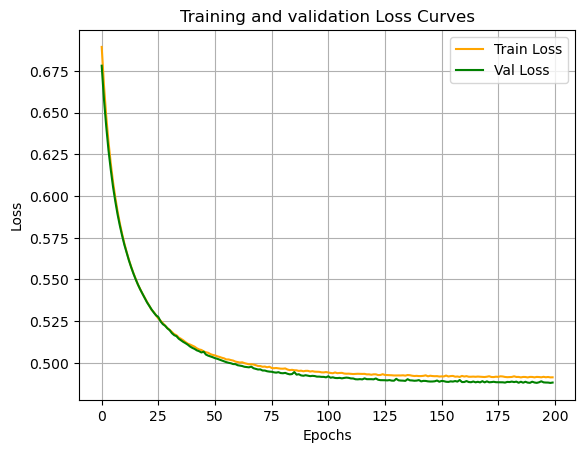

In [82]:
plt.plot(train_loss, linestyle='-', color='orange', label='Train Loss')
plt.plot(val_loss, linestyle='-', color='green', label='Val Loss')

plt.title("Training and validation Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.savefig('train_val_loss.png')
plt.show()




You might notice something odd -- the validation loss is lower than the train loss at the end of training. This is the opposite of what we would typically expect, however, note that the difference between these two curves is smaller than the expected level of statistical noise due to the sampling of the training and validation sets.

### Testing the model

In [83]:
model.load_state_dict(torch.load('log_reg_model.pth', weights_only=True))

with torch.no_grad():
    outputs = single_epoch(split='val', model=model, loader=test_loader,
                           criterion=criterion, lambdaL=lambdaL)

    y_true, y_pred, accuracy, precision, recall, f1, support, avg_loss = outputs

    print(f'Test scores:')
    print(f'\t accuracy: \t{accuracy:.4f}')
    print(f'\t precision: \t{precision.mean():.4f}')
    print(f'\t recall: \t{recall.mean():.4f}')
    print(f'\t f1-score: \t{f1.mean():.4f}')
    print(f'\t avg_loss: \t{avg_loss:.4f}')

Test scores:
	 accuracy: 	0.8040
	 precision: 	0.8044
	 recall: 	0.8043
	 f1-score: 	0.8040
	 avg_loss: 	0.4902


### Compare model weights to difference vectors


Now that we have a trained model that performs fairly well, we can compare the learned weights of the model to our difference vectors from earlier, again using cosine similarity.

We can also perform inference on these reviews; given our flipped reviews, we would expect a good classifier to output different labels for flipped versus unflipped reviews.

In [84]:
# Recall: `positive_diff` and `negative_diff` contained the difference vectors between positive/positive flipped and negative/negative flipped, respectively

# TODO: Retrieve the learned weights from the model
model_weights = model.linear.weight.detach().cpu().numpy()

# Dimensions of data
print(model_weights.shape)
print(positive_diff.shape)
print(negative_diff.shape)

num_samples_positive = positive_diff.shape[0]  # 5
num_samples_negative = negative_diff.shape[0]

# Reshape model_weights to match the number of samples
model_weights_repeated_positive = np.repeat(model_weights, num_samples_positive, axis=0)  # Shape: (5, 128)
model_weights_repeated_negative = np.repeat(model_weights, num_samples_negative, axis=0)

# TODO: Stack the model weights on top of the positive and negative difference vectors
# We recommend using `np.concatenate()`
positive_diff_weights = np.concatenate((model_weights_repeated_positive, positive_diff), axis=1) 
negative_diff_weights = np.concatenate((model_weights_repeated_negative, negative_diff), axis=1)


# TODO: Calculate cosine similarity between the learned weights and difference vectors
positive_weights_cosine = cosine_similarity_matrix(model_weights_repeated_positive, positive_diff)[:, 0]  
negative_weights_cosine = cosine_similarity_matrix(model_weights_repeated_negative, negative_diff)[:, 0]

print("Cosine similarity between learned weights and positive difference vectors (first column):")
print(positive_weights_cosine)
print("\n")
print("Cosine similarity between learned weights and negative difference vectors (first column):")
print(negative_weights_cosine)
''''''


(1, 128)
(5, 128)
(5, 128)
Cosine similarity between learned weights and positive difference vectors (first column):
[0.20324996 0.20324996 0.20324996 0.20324996 0.20324996]


Cosine similarity between learned weights and negative difference vectors (first column):
[-0.41074905 -0.41074905 -0.41074905 -0.41074905 -0.41074905]


''

In [85]:
# TODO: Use the embeddings of the positive reviews, positive flipped reviews, negative reviews, and negative flipped reviews as input to our trained model
positive_preds = model(torch.tensor(positive_embeddings, dtype=torch.float32).to(DEVICE))
positive_flipped_preds = model(torch.tensor(positive_flipped_embeddings, dtype=torch.float32).to(DEVICE))
negative_preds = model(torch.tensor(negative_embeddings, dtype=torch.float32).to(DEVICE))
negative_flipped_preds = model(torch.tensor(negative_flipped_embeddings, dtype=torch.float32).to(DEVICE))

# TODO: Convert predicted probabilities to classes using 0.5 as the classification threshold
positive_preds = (positive_preds.detach().cpu().numpy() > 0.5).astype(int)
positive_flipped_preds = (positive_flipped_preds.detach().cpu().numpy() > 0.5).astype(int)
negative_preds = (negative_preds.detach().cpu().numpy() > 0.5).astype(int)
negative_flipped_preds = (negative_flipped_preds.detach().cpu().numpy() > 0.5).astype(int)

print("Predictions for positive reviews:")
print(positive_preds)
print("\n")
print("Predictions for positive flipped reviews:")
print(positive_flipped_preds)
print("\n")
print("Predictions for negative reviews:")
print(negative_preds)
print("\n")
print("Predictions for negative flipped reviews:")
print(negative_flipped_preds)

Predictions for positive reviews:
[[1]
 [1]
 [0]
 [1]
 [1]]


Predictions for positive flipped reviews:
[[1]
 [1]
 [0]
 [0]
 [0]]


Predictions for negative reviews:
[[0]
 [0]
 [0]
 [0]
 [0]]


Predictions for negative flipped reviews:
[[1]
 [0]
 [1]
 [0]
 [0]]


The model does decently well when performing inference on both sets of un-flipped embeddings, right at 80% accuracy which is very in line with the test set accuracy we saw earlier. However, on the flipped embeddings, the model makes more mistakes. Why do you think this is the case? Do you think this behavior would generalize if we were to create more flipped reviews?

### Q3.3.4 Deliverable: Heatmaps of normalized weights and embeddings

Using a heatmap, we can display the normalized weights of the trained model alongside the difference vectors. The row above the black line is the normalized weights of the learned model and the rows below the black line are the normalized difference vectors we calculated at the beginning of the notebook.

The embeddings of the negative difference vectors have been negated such that they represent sentiment changes going from positive to negative sentiment (as opposed to negative to positive sentiment, which is what they originally represented). This is to make the heatmaps more comparable as we are now visualizing our learned weights against two sets of positive-to-negative sentiment changes.

Because the feature space is not interpretable, it may be hard to gain intuition from these heatmaps, but they will help us grade your work.

Please save the plot generated by the code below using `plt.savefig('your_figname.pdf')` (or take a screenshot of the plot) and include it in your response for Q3.3.6 on the written homework.

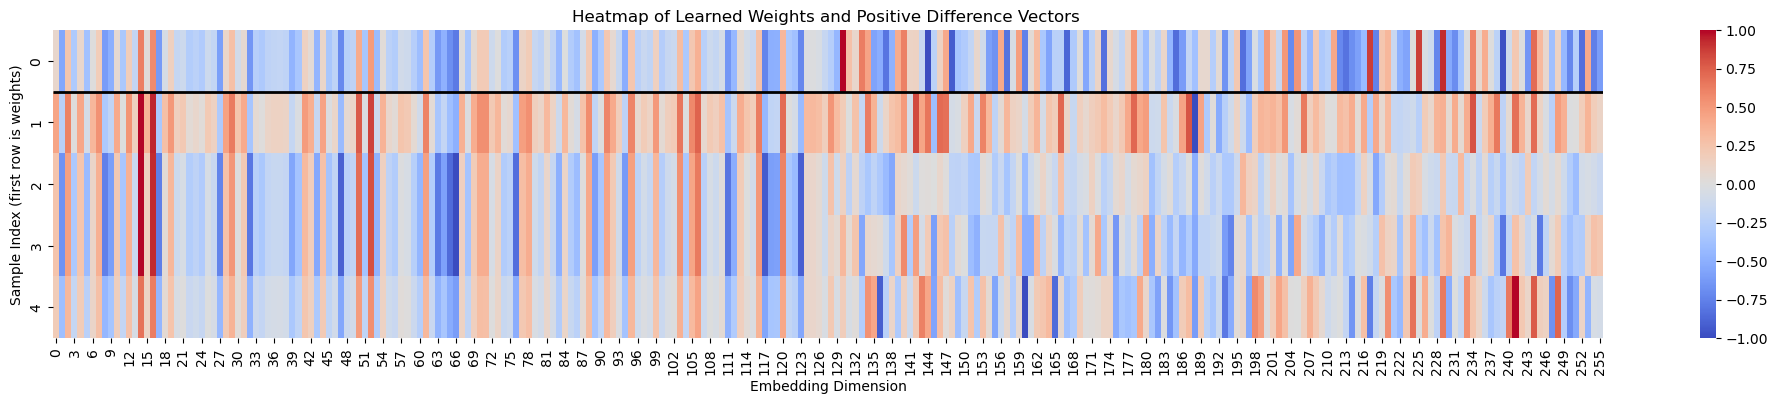

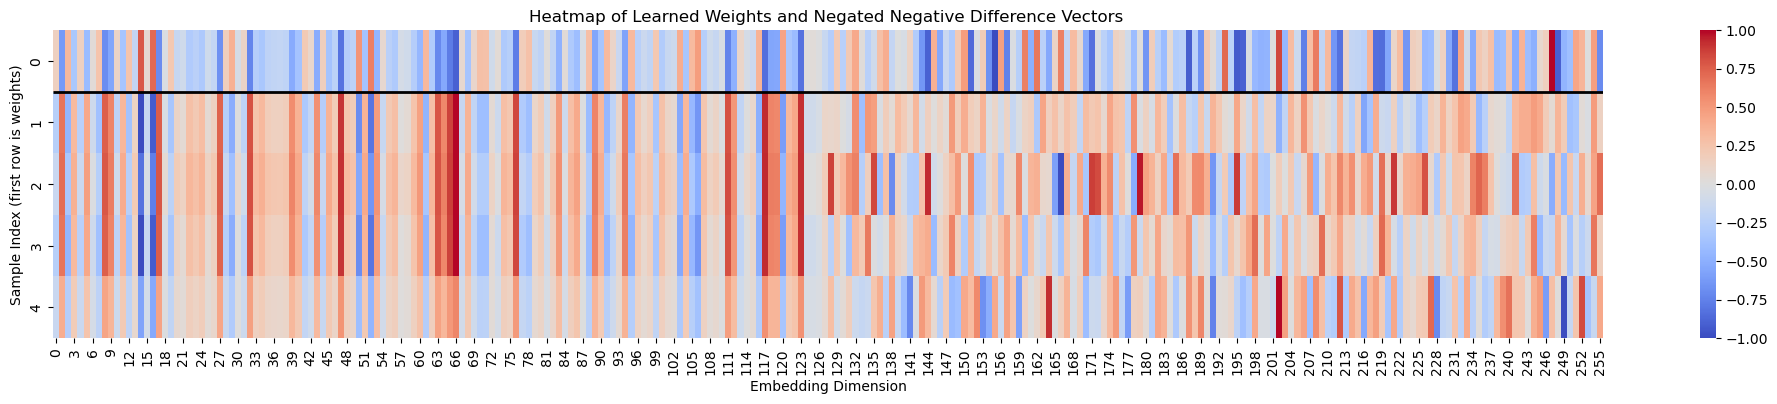

In [86]:
plt.figure(figsize=(25,4))
ax = sns.heatmap(normalize_rows(positive_diff_weights), cmap='coolwarm', center=0)
ax.hlines([1], *ax.get_xlim(), colors="black", linewidth=2)
plt.xlabel("Embedding Dimension")
plt.ylabel("Sample Index (first row is weights)")
plt.title("Heatmap of Learned Weights and Positive Difference Vectors ")
plt.savefig('positive_heatmap.png')
plt.show()
# # Uncomment this line and change the filename when you're ready to save your plot
# plt.savefig('your_figname.pdf')

# Negating the negative difference vectors (not the first row, which contains our weights!)
negative_diff_weights[1:] = negative_diff_weights[1:] * -1

plt.figure(figsize=(25,4))
ax = sns.heatmap(normalize_rows(negative_diff_weights), cmap='coolwarm', center=0)
ax.hlines([1], *ax.get_xlim(), colors="black", linewidth=2)
plt.xlabel("Embedding Dimension")
plt.ylabel("Sample Index (first row is weights)")
plt.title("Heatmap of Learned Weights and Negated Negative Difference Vectors ")
plt.savefig('negative_heatmap.png')
plt.show()
# # Uncomment this line and change the filename when you're ready to save your plot
# plt.savefig('your_figname.pdf')

In [89]:
print(model_weights)

[[ 0.1426404  -0.23373175  0.23214473 -0.08923489  0.14186089 -0.13464569
   0.08804087  0.19392401 -0.26883194 -0.2044096   0.12697881 -0.10063609
   0.19153254 -0.01519447  0.45022365  0.10293528  0.42000484 -0.27297774
   0.0530542   0.17882566 -0.00842919  0.01905349 -0.074849   -0.04710113
  -0.0816672   0.01798493 -0.0197945  -0.262042    0.15079686  0.2512924
   0.03690875  0.12688234 -0.28697714 -0.06434996 -0.09208622 -0.03609773
  -0.02369029 -0.02153456 -0.03198872 -0.18951698 -0.10954474  0.17027864
   0.11333404 -0.18337075  0.14989604 -0.10926584 -0.03890859 -0.33034995
  -0.0621509  -0.03783729  0.3228623  -0.10995544  0.37177148 -0.15832411
   0.10368321 -0.04798744 -0.07619484  0.03662171  0.02025068 -0.06358782
  -0.14860526  0.23229404 -0.07511049 -0.28166777 -0.19787736 -0.3120255
  -0.37006542  0.10592894 -0.10598774  0.11858626  0.20282541  0.20219359
   0.02076812  0.0890998  -0.07766435 -0.05584778 -0.30551633  0.1597431
   0.20133331 -0.00402832 -0.03714996  0.

# Remember to submit this notebook on Gradescope and respond to the questions in the written handout!